# Overheat PC analysys

In [2]:
import chardet

with open("Dataset\\25_10_13_1646-fortnite.csv", 'rb') as f:
    result = chardet.detect(f.read(10000))
    print(result)

{'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("Dataset\\25_10_13_1646-fortnite.csv", encoding='latin1', index_col='Time')
data.head()

,Date,Virtual Memory Committed [MB],Virtual Memory Available [MB],Virtual Memory Load [%],Physical Memory Used [MB],Physical Memory Available [MB],Physical Memory Load [%],Page File Usage [%],Core VIDs (avg) [V],P-core 0 VID [V],...,Total UP [MB],Current DL rate [KB/s],Current UP rate [KB/s],Total DL [MB].1,Total UP [MB].1,Current DL rate [KB/s].1,Current UP rate [KB/s].1,Total Errors [],GPU PCIe +12V Input Power [W],Unnamed: 502
Time,,,,,,,,,,,,,,,,,,,,,
13:13:27.164,13.10.2025,17420,51997,25.0,11547,53773,17.6,0.0,1.272,1.294,...,5,2.6,1.6,0,0,0.0,0.0,0,1.421,NaN
13:13:29.163,13.10.2025,17501,51915,25.2,11636,53684,17.8,0.0,1.265,1.276,...,5,0.6,0.6,0,0,0.0,0.0,0,0.012,NaN
13:13:31.161,13.10.2025,18001,51415,25.9,12016,53304,18.3,0.0,1.270,1.263,...,5,4.6,4.8,0,0,0.0,0.0,0,1.518,NaN
13:13:33.165,13.10.2025,17875,51542,25.7,12134,53186,18.5,0.0,1.279,1.313,...,5,4.8,1.3,0,0,0.0,0.0,0,1.469,NaN
13:13:35.168,13.10.2025,18038,51378,25.9,11875,53445,18.1,0.0,1.278,1.315,...,5,3.7,1.8,0,0,0.0,0.0,0,1.458,NaN


# CPU Package

Temp MAX: 94.00 °C
Temp MIN: 44.00 °C
Temp PROM: 82.35 °C


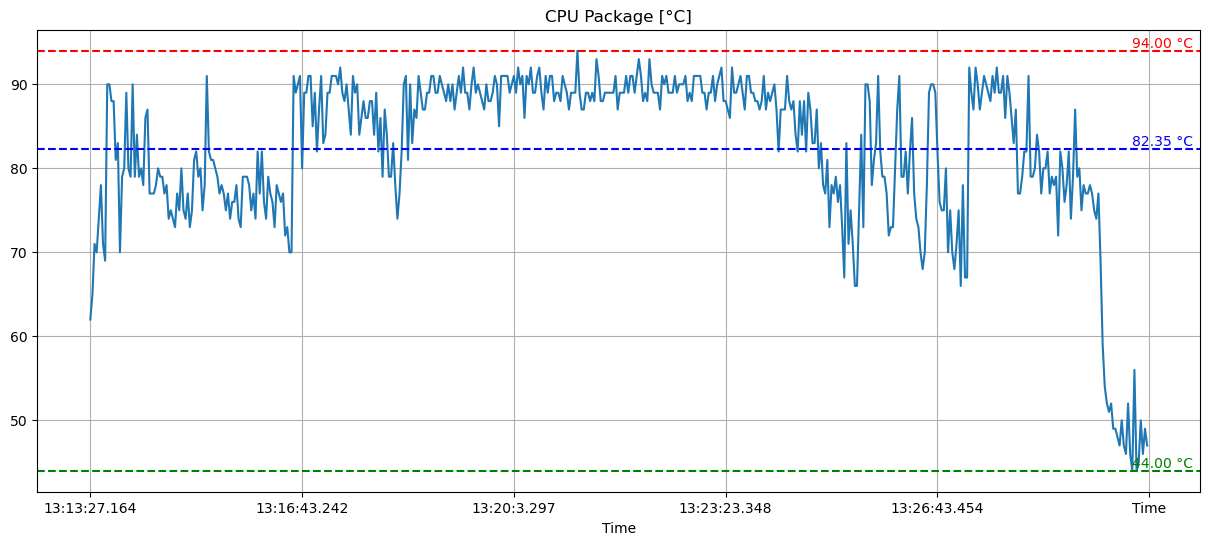

In [4]:
cpuPackage_T = pd.to_numeric(data['CPU Package [°C]'], errors='coerce') #Convierte los valores no numericos a NaN, pandas lo ignora al hacer calculos

max_temp = cpuPackage_T.max()
avg_temp = cpuPackage_T.mean()
min_temp = cpuPackage_T.min()

print(f"Temp MAX: {max_temp:.2f} °C")
print(f"Temp MIN: {min_temp:.2f} °C")
print(f"Temp PROM: {avg_temp:.2f} °C")

ax = cpuPackage_T.plot(figsize=(15,6), label='CPU Package [°C]', grid=True)

# Línea del promedio
plt.axhline(y=max_temp, color='red', linestyle='--', label=f'Máximo: {max_temp:.2f} °C')
plt.axhline(y=min_temp, color='green', linestyle='--', label=f'Mínimo: {min_temp:.2f} °C')
plt.axhline(y=avg_temp, color='blue', linestyle='--', label=f'Promedio: {avg_temp:.2f} °C')

# Anotar los valores al lado derecho de la gráfica
x_pos = len(cpuPackage_T) * 0.98  # cerca del final del eje X

plt.text(x_pos, max_temp, f'{max_temp:.2f} °C', color='red', va='bottom', ha='left')
plt.text(x_pos, min_temp, f'{min_temp:.2f} °C', color='green', va='bottom', ha='left')
plt.text(x_pos, avg_temp, f'{avg_temp:.2f} °C', color='blue', va='bottom', ha='left')

plt.title('CPU Package [°C]')

#Mostrar grafico
plt.show()


# AIO Pump

In [5]:
data['AIO Pump [RPM]']

Time
13:13:27.164                                                 3461
13:13:29.163                                                 3479
13:13:31.161                                                 3461
13:13:33.165                                                 3479
13:13:35.168                                                 3470
                                      ...                        
13:29:55.455                                                 3409
13:29:57.460                                                 3426
13:29:59.458                                                 3400
Time                                               AIO Pump [RPM]
NaN             ASUS ROG STRIX B760-I GAMING WIFI (Nuvoton NCT...
Name: AIO Pump [RPM], Length: 502, dtype: object

MAX: 3543.0 RPM
MIN: 3292.0 RPM
PROM: 3437.346 RPM


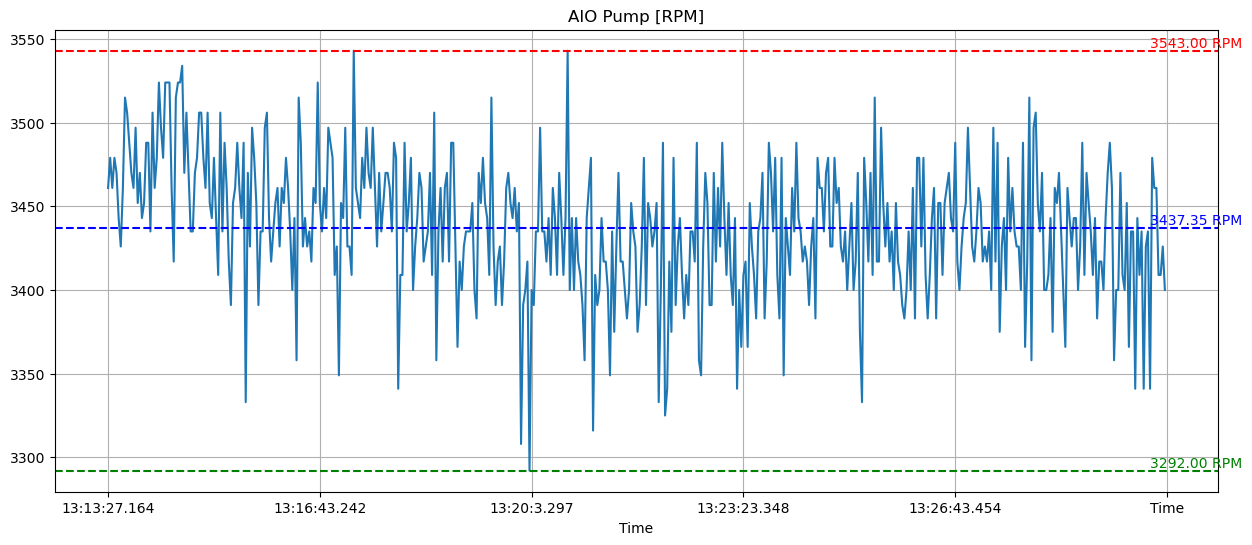

In [6]:
sensor = pd.to_numeric(data['AIO Pump [RPM]'], errors='coerce') #Convierte los valores no numericos a NaN, pandas lo ignora al hacer calculos

avg = sensor.mean()
max = sensor.max()
min = sensor.min()

print(f"MAX: {max} RPM")
print(f"MIN: {min} RPM")
print(f"PROM: {avg} RPM")

ax = sensor.plot(figsize=(15,6), label='AIO Pump [RPM]', grid=True)

# Línea del promedio
plt.axhline(y=max, color='red', linestyle='--', label=f'Máximo: {max:.2f} °C')
plt.axhline(y=min, color='green', linestyle='--', label=f'Mínimo: {min:.2f} °C')
plt.axhline(y=avg, color='blue', linestyle='--', label=f'Promedio: {avg:.2f} °C')

# Anotar los valores al lado derecho de la gráfica
x_pos = len(sensor) * 0.98  # cerca del final del eje X

plt.text(x_pos, max, f'{max:.2f} RPM', color='red', va='bottom', ha='left')
plt.text(x_pos, min, f'{min:.2f} RPM', color='green', va='bottom', ha='left')
plt.text(x_pos, avg, f'{avg:.2f} RPM', color='blue', va='bottom', ha='left')

plt.title('AIO Pump [RPM]')

#Mostrar grafico
plt.show()

# Comprovar si el throttling es sostenido

Observa las columnas:
- Core Thermal Throttling (yes/No)
- Core Max Temp
- Effective Clock (MHz)

Si el _Core Effective Clock_ es menor que a _Core Clock_  (200-500MHz o más) durante todo el tiempo, entonces el throttling es sostenido.
Si solo ves picos ocasionales en "YES", es intermitente y aceptable.

In [19]:
selected_col = ['Core Thermal Throttling (avg) [Yes/No]', 'Core Max [°C]', 
                'Core Effective Clocks (avg) [MHz]', 'Core Clocks (avg) [MHz]']
#selected_col = ['Core Effective Clocks (avg) [MHz]', 'Core Clocks (avg) [MHz]']
subset_df = data[selected_col]
subset_df.head(20)


,Core Thermal Throttling (avg) [Yes/No],Core Max [°C],Core Effective Clocks (avg) [MHz],Core Clocks (avg) [MHz]
Time,,,,
13:13:27.164,No,61,737.2,4031.8
13:13:29.163,No,65,785.9,3998.6
13:13:31.161,No,71,952.5,3740.9
13:13:33.165,No,66,837.8,4389.3
13:13:35.168,No,74,806.5,4389.3
13:13:37.171,No,80,985.5,3757.5
13:13:39.166,No,70,893.9,4389.3
13:13:41.174,No,78,1013.5,3998.6
13:13:43.170,Yes,90,4013.2,4023.5


In [18]:

subset_df['Core Clocks (avg) [MHz]'] = pd.to_numeric(subset_df['Core Clocks (avg) [MHz]'], errors='coerce')
subset_df['Core Effective Clocks (avg) [MHz]'] = pd.to_numeric(subset_df['Core Effective Clocks (avg) [MHz]'], errors='coerce')

subset_df['Throttling Sostenido'] = subset_df['Core Clocks (avg) [MHz]'] - subset_df['Core Effective Clocks (avg) [MHz]']
subset_df['Throttling Sostenido'] = subset_df['Throttling Sostenido'].round(4)

subset_df.head(20)


C:\Users\roly_\AppData\Local\Temp\ipykernel_33364\1791902094.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df['Core Clocks (avg) [MHz]'] = pd.to_numeric(subset_df['Core Clocks (avg) [MHz]'], errors='coerce')
C:\Users\roly_\AppData\Local\Temp\ipykernel_33364\1791902094.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df['Core Effective Clocks (avg) [MHz]'] = pd.to_numeric(subset_df['Core Effective Clocks (avg) [MHz]'], errors='coerce')
C:\Users\roly_\AppData\Local\Temp\ipykernel_33364\

,Core Effective Clocks (avg) [MHz],Core Clocks (avg) [MHz],Throttling Sostenido
Time,,,
13:13:27.164,737.2,4031.8,3294.6
13:13:29.163,785.9,3998.6,3212.7
13:13:31.161,952.5,3740.9,2788.4
13:13:33.165,837.8,4389.3,3551.5
13:13:35.168,806.5,4389.3,3582.8
13:13:37.171,985.5,3757.5,2772.0
13:13:39.166,893.9,4389.3,3495.4
13:13:41.174,1013.5,3998.6,2985.1
13:13:43.170,4013.2,4023.5,10.3


# GPT Analysis

Antes de graficar, confirmemos qué columnas específicas usaremos para entender el thermal throttling y el comportamiento del reloj (clock throttling).

Estas son las columnas que nos interesan (y que ya están en tu CSV):

🧊 Temperatura: "Core Max [°C]" o "CPU Package [°C]"

⚙️ Core Effective Clocks (avg) [MHz]` — el valor real promedio al que corren los núcleos

⚡ Core Clocks (avg) [MHz]` — la frecuencia nominal o target

🔥 Core Thermal Throttling (avg) [Yes/No]` — indica si hubo limitación por temperatura

Con estos datos, puedo graficar el comportamiento térmico y de frecuencia a lo largo del tiempo para ver cuándo y cuánto tiempo estuvo limitado por temperatura.

¿Quieres que la gráfica muestre todo el periodo de la sesión (desde que se abrió el juego hasta que cerraste), o que la recorte a la parte donde la temperatura sube (por ejemplo, a partir de los 70 °C)?

In [ ]:
selected_col = ['Core Max [°C]', 'CPU Package [°C]', 'Core Effective Clocks (avg) [MHz]',
                 'Core Clocks (avg) [MHz]', 'Core Thermal Throttling (avg) [Yes/No]' ]
subset_df = data[selected_col]
subset_df.head(20)

subset_df['Core Max [°C]'] = pd.to_numeric(subset_df['Core Max [°C]'], errors='coerce')

for col in selected_col:
    subset_df[col] = pd.to_numeric(subset_df[col], errors='coerce')


<class 'pandas.core.frame.DataFrame'>
Index: 502 entries, 13:13:27.164 to nan
Data columns (total 5 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Core Max [°C]                           500 non-null    float64
 1   CPU Package [°C]                        500 non-null    float64
 2   Core Effective Clocks (avg) [MHz]       500 non-null    float64
 3   Core Clocks (avg) [MHz]                 500 non-null    float64
 4   Core Thermal Throttling (avg) [Yes/No]  0 non-null      float64
dtypes: float64(5)
memory usage: 39.7+ KB


C:\Users\roly_\AppData\Local\Temp\ipykernel_33364\3408772335.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df['Core Max [°C]'] = pd.to_numeric(subset_df['Core Max [°C]'], errors='coerce')
C:\Users\roly_\AppData\Local\Temp\ipykernel_33364\3408772335.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df[col] = pd.to_numeric(subset_df[col], errors='coerce')


In [42]:
subset_df.head()

,Core Max [°C],CPU Package [°C],Core Effective Clocks (avg) [MHz],Core Clocks (avg) [MHz],Core Thermal Throttling (avg) [Yes/No]
Time,,,,,
13:13:27.164,61.0,62.0,737.2,4031.8,NaN
13:13:29.163,65.0,65.0,785.9,3998.6,NaN
13:13:31.161,71.0,71.0,952.5,3740.9,NaN
13:13:33.165,66.0,70.0,837.8,4389.3,NaN
13:13:35.168,74.0,74.0,806.5,4389.3,NaN


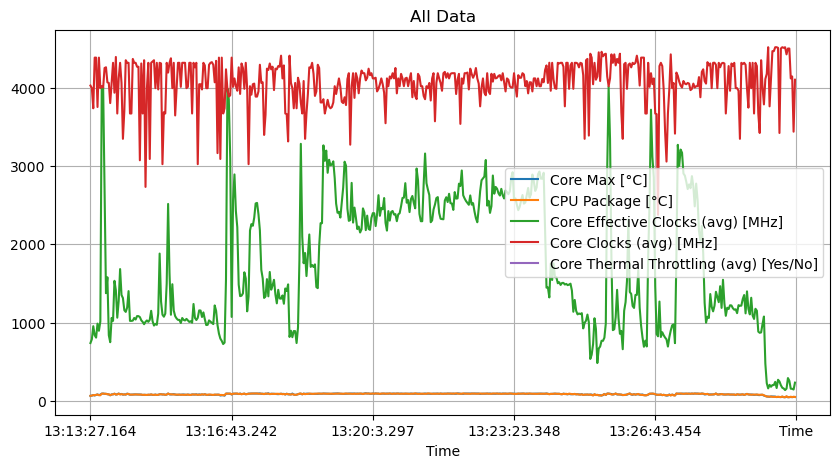

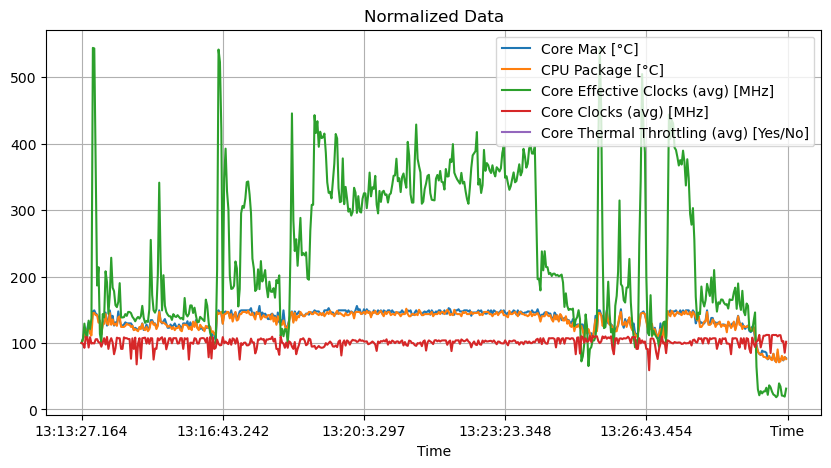

In [41]:
#(subset_df * 100).plot(figsize=(10,5), grid=True)
subset_df.plot(figsize=(10,5), grid=True)
plt.title('All Data')
#Normalized data
(subset_df / subset_df.iloc[0] * 100).plot(figsize=(10,5), grid=True)
plt.title('Normalized Data')
plt.show()

# Chat GPT Code

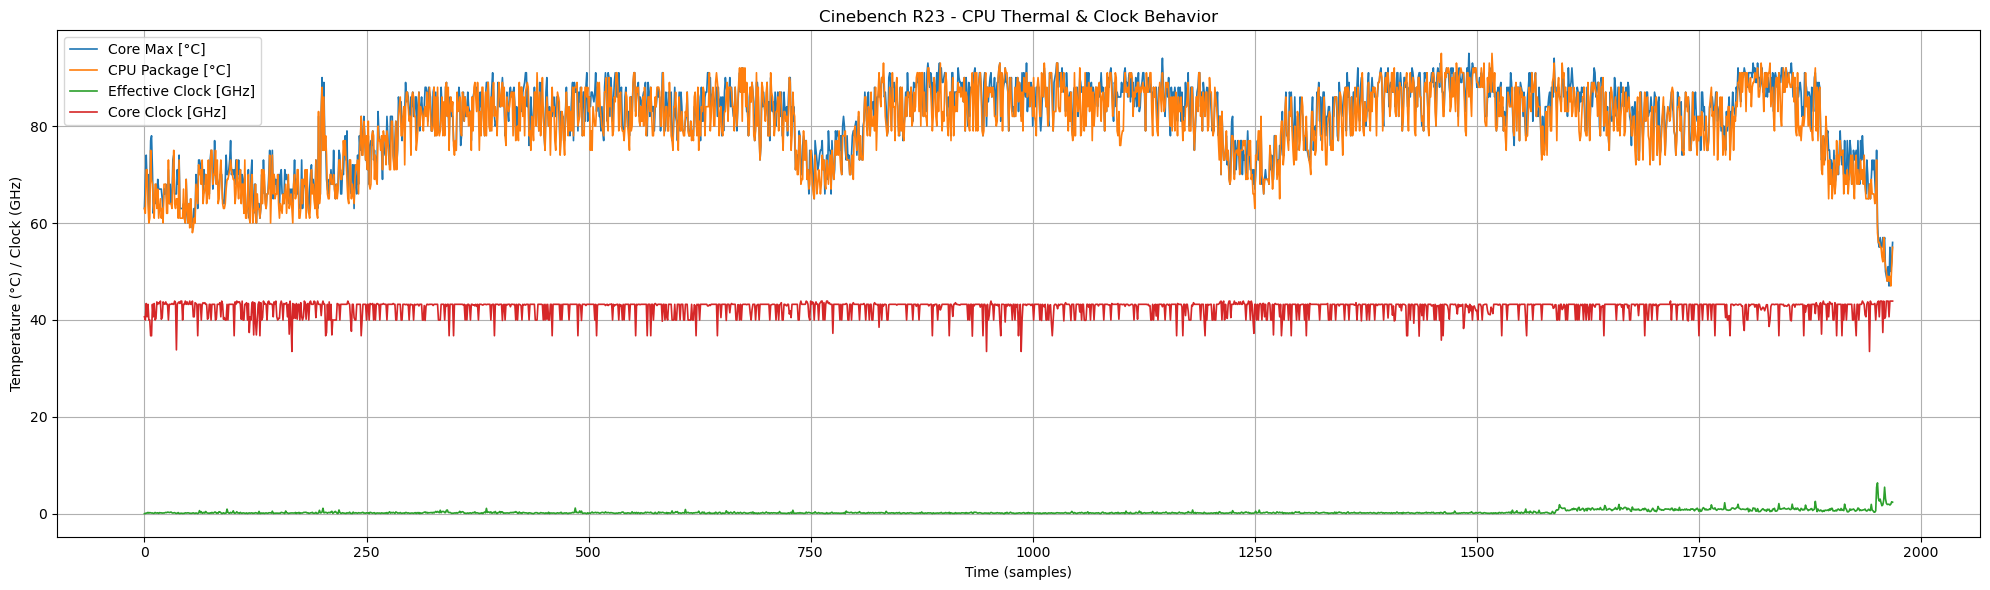

{'Avg Core Temp (°C)': np.float64(81.41239207719654),
 'Max Core Temp (°C)': np.int64(95),
 'Avg CPU Package (°C)': np.float64(80.01777552056882),
 'Max CPU Package (°C)': np.float64(95.0),
 'Avg Effective Clock (GHz)': np.float64(36.68816658202133),
 'Max Effective Clock (GHz)': np.float64(639.3),
 'Avg Target Clock (GHz)': np.float64(4241.365210766888),
 'Max Target Clock (GHz)': np.float64(4390.3)}

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "Dataset/2025_10_28_2143-battlefield.CSV"
#"Dataset\\25_10_13_1646-fortnite.csv"


# Detectar encabezado y abrir con codificación flexible
with open(file_path, "r", encoding="latin-1", errors="ignore") as f:
    lines = f.readlines()

header_index = None
# Busca la columna de time y lo asigna como index
for i, line in enumerate(lines):
    if "Time" in line:
        header_index = i
        break

df = pd.read_csv(file_path, skiprows=header_index, encoding="latin-1")
df = df.dropna(axis=1, how="all") # Elimina filas vacias

# Filtrar columnas relevantes
# Lista por comprension [<neva_variable> for <elemento> in <iterable> if <condicion>]
# es equivalente al siguente bloque
""" cols = []
for c in df.columns:
    if any(x in c for x in [...]):
        cols.append(c) """

cols = [c for c in df.columns if any(x in c for x in [
    "Core Max", "CPU Package", "Core Thermal Throttling", "Core Effective Clocks", "Core Clocks"
])]
data = df[cols].copy()

# Convertir a numérico
for c in data.columns:
    data[c] = pd.to_numeric(data[c], errors="coerce")

# Graficar comportamiento térmico y frecuencia
# plt.plot(eje_x, eje_y, )
plt.figure(figsize=(20, 6))
plt.plot(data.index, data.filter(like="Core Max").iloc[:, 0], label="Core Max [°C]", linewidth=1.2)
plt.plot(data.index, data.filter(like="CPU Package").iloc[:, 0], label="CPU Package [°C]", linewidth=1.2)
plt.plot(data.index, data.filter(like="Core Effective Clocks").iloc[:, 0] / 100, label="Effective Clock [GHz]", linewidth=1.2)
plt.plot(data.index, data.filter(like="Core Clocks").iloc[:, 0] / 100, label="Core Clock [GHz]", linewidth=1.2)

plt.title("Cinebench R23 - CPU Thermal & Clock Behavior")
plt.xlabel("Time (samples)")
plt.ylabel("Temperature (°C) / Clock (GHz)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcular resumen
summary = {
    "Avg Core Temp (°C)": data.filter(like="Core Max").mean().iloc[0],
    "Max Core Temp (°C)": data.filter(like="Core Max").max().iloc[0],
    "Avg CPU Package (°C)": data.filter(like="CPU Package").mean().iloc[0],
    "Max CPU Package (°C)": data.filter(like="CPU Package").max().iloc[0],
    "Avg Effective Clock (GHz)": (data.filter(like="Core Effective Clocks").mean().iloc[0]),
    "Max Effective Clock (GHz)": (data.filter(like="Core Effective Clocks").max().iloc[0]),
    "Avg Target Clock (GHz)": (data.filter(like="Core Clocks").mean().iloc[0]),
    "Max Target Clock (GHz)": (data.filter(like="Core Clocks").max().iloc[0]),
}

summary


"Dataset/2025_10_21_2144-fortnite.CSV"
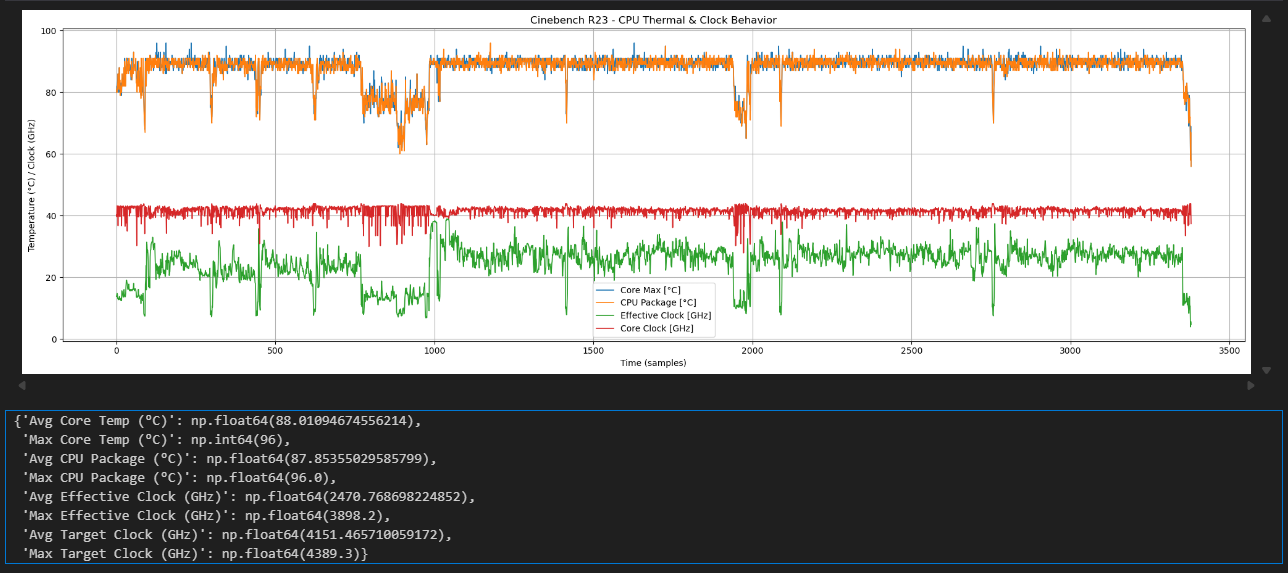